In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from pathlib import Path
import sys
import os
sys.path.append(os.path.abspath("/home/anushkasingh/Desktop/Thesis/Code/BaselineInvariance"))
from augment import BaselineGenerator
from model import SpecEncoder
from train import train_contrastive
from evaluate import compute_invariance, plot_umap
from utils import plot_spectra
from data_loader import load_healthy


/home/anushkasingh/Desktop/Thesis/Code/thesis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'model'

In [11]:
from pathlib import Path
import sys
import os

# Add BaselineInvariance folder to Python path
sys.path.append(os.path.abspath("/home/anushkasingh/Desktop/Thesis/Code/BaselineInvariance"))

from data_loader import load_healthy


spectra, wn_ref, filenames, normVP, infoP = load_healthy()

print("Spectra shape:", spectra.shape)
print("Wavenumbers shape:", wn_ref.shape)
print("Example filename:", filenames[0])
print("Normalization factor (first 5):", normVP[:5])
print("Metadata example:", infoP[0:5])


✅ Loaded 20171109-01-EL-TB-8y.01.dpt (VP=420, Sex=F)
✅ Loaded 20171109-02-PL-TB-5y.02.dpt (VP=420, Sex=M)
✅ Loaded 20171109-04-OG-TB-M1.04.dpt (VP=428, Sex=M)
✅ Loaded 20171109-06-TA-TB-M1.06.dpt (VP=448, Sex=F)
✅ Loaded 20171109-16-AL-TB-M1.16.dpt (VP=417, Sex=F)
✅ Loaded 20171109-17-AH-TB-M1.17.dpt (VP=430, Sex=F)
✅ Loaded 20171109-22-SR-TB-M1.22.dpt (VP=420, Sex=F)
✅ Loaded 20171109-26-ML-TB-M1.26.dpt (VP=449, Sex=M)
✅ Loaded 20171123-04-KM-TB.dpt (VP=483, Sex=M)
✅ Loaded 20171123-18-AA-ExD.dpt (VP=499, Sex=M)
✅ Loaded 20180125-22-TS-TB.dpt (VP=438, Sex=M)
✅ Loaded 20180205-01-OL-TB.dpt (VP=465, Sex=F)
✅ Loaded 20180205-16-CW-TB.16.dpt (VP=438, Sex=M)
✅ Loaded 20180205-17-MG-TB.17.dpt (VP=428, Sex=M)
✅ Loaded 20180802-05-MF-TB.dpt (VP=503, Sex=F)
✅ Loaded 20190312-12-EF-DB.dpt (VP=505, Sex=M)
✅ Loaded 20190405-02-001.dpt (VP=504, Sex=M)
✅ Loaded 20190405-05-004.dpt (VP=454, Sex=M)
✅ Loaded 20190606-07-015.dpt (VP=515, Sex=M)
✅ Loaded 20190606-08-016.dpt (VP=441, Sex=M)
✅ Loaded 2019

In [14]:
print("Loaded spectra shape:", spectra.shape)
print("First filenames:", filenames[:3])
print("Normalization VP:", normVP)

Loaded spectra shape: (22, 14517)
First filenames: ['20171109-01-EL-TB-8y.01', '20171109-02-PL-TB-5y.02', '20171109-04-OG-TB-M1.04']
Normalization VP: [420 420 428 448 417 430 420 449 483 499 438 465 438 428 503 505 504 454
 515 441 404 363]


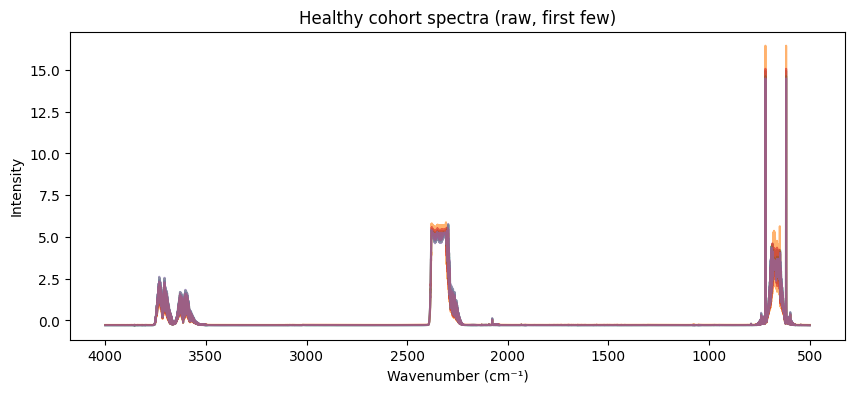

In [15]:

# Inspect a few raw spectra ---
plt.figure(figsize=(10,4))
for i in range(min(5, spectra.shape[0])):
    plt.plot(wn_ref, spectra[i], alpha=0.6)
plt.gca().invert_xaxis()
plt.title("Healthy cohort spectra (raw, first few)")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Intensity")
plt.show()

In [12]:
# Normalize each spectrum to target VP = 500
target_vp = 500
scale_factors = target_vp / normVP
spectra = spectra * scale_factors[:, None]

print("Applied vapor pressure normalization to 500 mbar.")


Applied vapor pressure normalization to 500 mbar.


In [13]:
# Standard Normal Variate (SNV) normalization
spectra = (spectra - spectra.mean(axis=1, keepdims=True)) / spectra.std(axis=1, keepdims=True)

print("SNV normalization done. Shape:", spectra.shape)


SNV normalization done. Shape: (22, 14517)


In [16]:

# --- Step 3: Prepare for training ---
X = spectra.astype(np.float32)
y = np.zeros(len(X))  # only healthy data, single label for now

# --- Step 4: Train contrastive model ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model = ContrastiveEncoder(input_dim=X.shape[1]).to(device)

history = train_contrastive(model, X, epochs=50, batch_size=32, device=device)

# --- Step 5: Embedding & visualization ---
plot_umap(model, X, labels=y, title="UMAP projection of healthy cohort")

# --- Step 6: Save results ---
np.savez("healthy_embeddings.npz", embeddings=model.get_embeddings(X), filenames=filenames)

NameError: name 'ContrastiveEncoder' is not defined